In [1]:
import folium
import pandas as pd 
from scrapper.AlquilerScrapper import Scrapper
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm


Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [2]:
df = pd.read_csv("storage/arg_venta_data.csv")

df.isna().sum()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2997 non-null   int64  
 1   url               2997 non-null   object 
 2   precio            2997 non-null   object 
 3   expensas          1885 non-null   object 
 4   area_m2           2953 non-null   object 
 5   dormitorios       2583 non-null   object 
 6   antiguedad        2145 non-null   object 
 7   tipo_inmueble     2997 non-null   object 
 8   puntaje_arg_prop  2997 non-null   int64  
 9   imagen_path       2993 non-null   object 
 10  image_url         2997 non-null   object 
 11  lat               2932 non-null   float64
 12  lon               2932 non-null   float64
 13  valido_desde      2997 non-null   object 
 14  valido_hasta      0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 351.3+ KB


In [3]:
df = df[ df["lat"].notna() & df["lon"].notna() ]
df.info()
df[['lat','lon']].value_counts().head(100)


<class 'pandas.core.frame.DataFrame'>
Index: 2932 entries, 0 to 2995
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2932 non-null   int64  
 1   url               2932 non-null   object 
 2   precio            2932 non-null   object 
 3   expensas          1843 non-null   object 
 4   area_m2           2889 non-null   object 
 5   dormitorios       2525 non-null   object 
 6   antiguedad        2091 non-null   object 
 7   tipo_inmueble     2932 non-null   object 
 8   puntaje_arg_prop  2932 non-null   int64  
 9   imagen_path       2928 non-null   object 
 10  image_url         2932 non-null   object 
 11  lat               2932 non-null   float64
 12  lon               2932 non-null   float64
 13  valido_desde      2932 non-null   object 
 14  valido_hasta      0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 366.5+ KB


lat         lon       
-34.611210  -58.497830    9
-34.551860  -58.453583    8
-34.571570  -58.456500    8
-34.627830  -58.433530    7
-34.584830  -58.396340    7
                         ..
-34.573240  -58.441680    3
-34.610590  -58.399185    3
-34.578610  -58.413970    3
-34.637486  -58.460144    3
-34.571180  -58.431860    3
Name: count, Length: 100, dtype: int64

<Axes: >

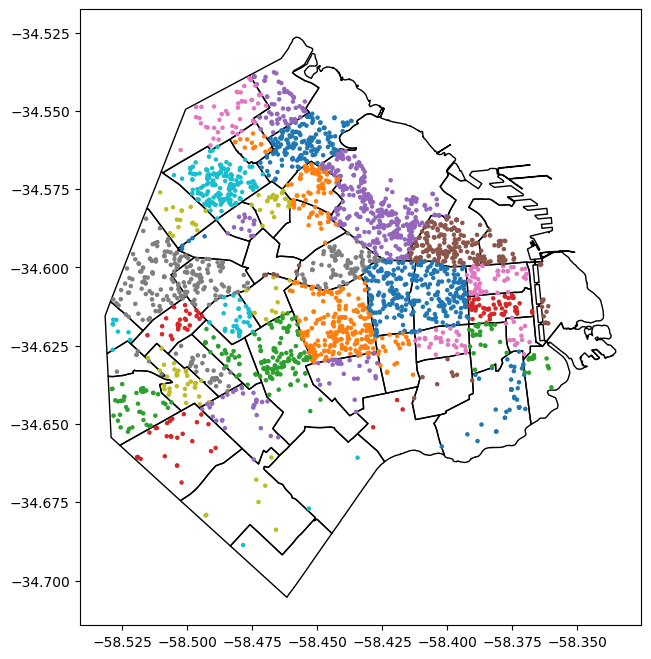

In [4]:


# Barrios
barrios = gpd.read_file("barrios.geojson")

# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf_join = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_join = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf_join.plot(
    ax=ax,
    column='nombre',
    markersize=5,
    legend=False
)


Elimino barrios con menos de 5 datos

In [5]:
gdf_join = gdf_join[
    gdf_join.groupby('nombre')['nombre'].transform('size') >= 5
]


La columna "dormitorios" tiene valores nulos cuando son monoambientes y valores del tipo string "1 dorm. , 2 dorm, etc" cuando no es monoambinete. Por esta razón, se emplea una nueva columna "ambientes" que contabiliza la cantidad de ambientes en función de los dormitorios y lo transforma en un numero entero.

In [6]:
gdf_join['dormitorios'] = gdf_join['dormitorios'].fillna(0)
gdf_join['ambientes'] = gdf_join['dormitorios'].astype(str).str.extract('(\d+)').astype(int) + 1
gdf_join['ambientes']

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0       1
1       3
2       3
3       3
4       2
       ..
2991    3
2992    2
2993    1
2994    4
2995    3
Name: ambientes, Length: 2919, dtype: int64

Vemos si hay dptos sin infor de superficie cubierta en m^2. En ese caso, rellenamos este dato con la mediana de los departamentos con esa cantidad de ambientes. El resto será descartado.

In [7]:

# convert area_m2 to numeric (extract numbers, handle commas and coercion)
gdf_join['area_m2'] = (
    gdf_join['area_m2']
    .astype(str)
    .str.extract(r'(\d+(?:[\.,]\d+)?)', expand=False)
    .str.replace(',', '.', regex=False)
)
gdf_join['area_m2'] = pd.to_numeric(gdf_join['area_m2'], errors='coerce')

mask = gdf_join['area_m2'].isna() & gdf_join['ambientes'].notna()

gdf_join.loc[mask, 'area_m2'] = (
    gdf_join.groupby('ambientes')['area_m2']
      .transform('median')
      .loc[mask]
)

print("cantidad de nulos en area_m2:", gdf_join['area_m2'].isna().sum())

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en area_m2: 0


In [8]:
gdf_join['expensas'] = (
    gdf_join['expensas']
        .str.extract(r'\$\s*([\d\.]+)')[0]   # toma 350.000
        .str.replace('.', '', regex=False)  # borra separador de miles
        .astype('float')
)


gdf_join['expensas'] = pd.to_numeric(gdf_join['expensas'], errors='coerce')

print("cantidad de nulos en expensas:", gdf_join['expensas'].isna().sum())

gdf_join['expensas'].fillna(0, inplace=True)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en expensas: 1080
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [9]:
gdf_join['precio']

0        USD 69.500 + $105.000 expensas
1                           USD 320.000
2        USD 84.900 + $110.000 expensas
3       USD 120.000 + $258.000 expensas
4        USD 58.000 + $142.000 expensas
                     ...               
2991     USD 59.900 + $105.000 expensas
2992      USD 64.900 + $99.000 expensas
2993                        USD 165.000
2994                        USD 179.900
2995    USD 239.000 + $140.000 expensas
Name: precio, Length: 2919, dtype: object

In [10]:
print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())

gdf_join["precio"] = gdf_join["precio"].str.findall(
    r"(?i)(usd|u\$s|\$)\s*([\d\.]+)"
)

print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())
gdf_join['precio'].where(gdf_join['precio'].isna(), None)



cantidad de nulos en precio: 0
cantidad de nulos en precio: 0


0       None
1       None
2       None
3       None
4       None
        ... 
2991    None
2992    None
2993    None
2994    None
2995    None
Name: precio, Length: 2919, dtype: object

Me quedo solo con el precio del alquiler. Los percios en dolar los transformo a pesos scrapeando el valor de ambitofinanciero
Borro los valores de alquiler menores a $100k por ser demasiado bajos

In [11]:
gdf_join['precio']

0        [(USD, 69.500), ($, 105.000)]
1                     [(USD, 320.000)]
2        [(USD, 84.900), ($, 110.000)]
3       [(USD, 120.000), ($, 258.000)]
4        [(USD, 58.000), ($, 142.000)]
                     ...              
2991     [(USD, 59.900), ($, 105.000)]
2992      [(USD, 64.900), ($, 99.000)]
2993                  [(USD, 165.000)]
2994                  [(USD, 179.900)]
2995    [(USD, 239.000), ($, 140.000)]
Name: precio, Length: 2919, dtype: object

In [12]:

gdf_join["precio"] = gdf_join["precio"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 1 else (np.nan, np.nan)
)
gdf_join = gdf_join[~gdf_join['precio'].apply(lambda x: pd.isna(x[0]))]

valor_dolar_oficial_venta = pd.read_csv("storage/dolar_hoy.csv").iloc[0]['valor']

gdf_join['precio'] = gdf_join['precio'].apply(
    lambda x: float(x[1].replace('.', '')) / valor_dolar_oficial_venta if x[0].lower() in ['$', '$ '] else float(x[1].replace('.', ''))
)   

gdf_join['precio'] = pd.to_numeric(gdf_join['precio'], errors='coerce')

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [13]:
gdf_join = gdf_join.drop(gdf_join[gdf_join['precio'] <= 8000]['precio'].index)

Columna precio por metro cuadrádo 

In [14]:
gdf_join['precio_m2'] = gdf_join['precio'] / gdf_join['area_m2']


EDA

analicemos la relación entre el precio final y la cantidad de ambientes.
Quiero: tomar una zona con puntos parecidos y luego, para cada conjunto de ambientes estimar la relacion entre el precio y la superficie cubierta.
Si vemos que las tendencias son distintas para cada conjunto con ambientes, luego podría existir una dependencia con la cantidad de ambientes en el precio final. 
Por ejemplo, podría pasar que al tener menos demanda los departamentos con muchos ambientes, estos tiendan a no aumentar tanto el precio en relación a los que tinene menos ambientes en comparación al aumento de precio de tener 1 ambiente a 2 ambientes bajo la misme superficie cubierta.

In [15]:
densidad_naive = (
    gdf_join
    .groupby('nombre')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


nombre
Palermo          381
Caballito        261
Villa Urquiza    188
Recoleta         187
Belgrano         177
dtype: int64

In [16]:
gdf_palermo = gdf_join[ gdf_join['nombre'] == 'Palermo' ]
gdf_caballito = gdf_join[ gdf_join['nombre'] == 'Caballito' ]

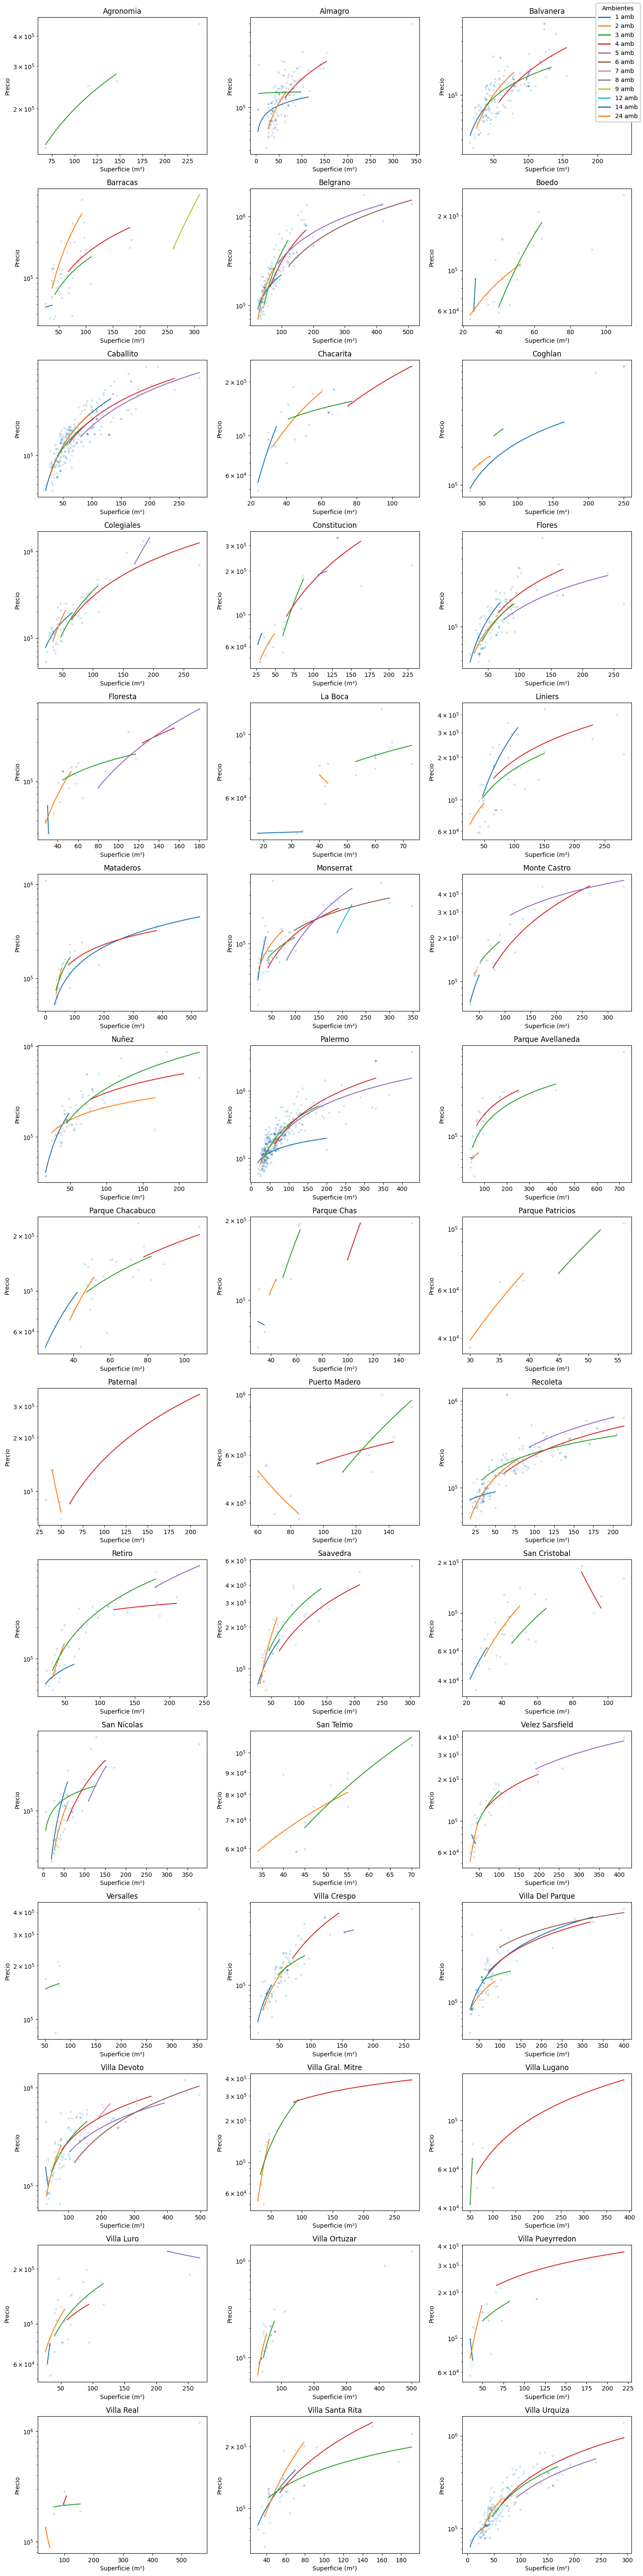

In [17]:
################## cambiar min obs ##################
min_obs = 1

barrios_con_observaciones = (
    gdf_join
    .groupby('nombre')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf_join['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf_join[gdf_join['nombre'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2'],
        gdf_b['precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(np.log(sub['area_m2']))
        y = np.log(sub['precio'])

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2'].min(),
            sub['area_m2'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(np.log(x_grid))
        )

        ax.plot(
            x_grid,
            np.exp(y_hat),
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )


    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('Precio')
    ax.set_yscale('log')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [18]:
gdf_join['superficie_por_ambientes'] = gdf_join['area_m2'] / gdf_join['ambientes']

# analisis de antiguedad


In [19]:
gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,tipo_inmueble,puntaje_arg_prop,imagen_path,...,lon,valido_desde,valido_hasta,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes
0,8369836,https://www.argenprop.com/departamento-en-vent...,69500.0,105000.0,45.0,0,NaN,departamento,1,images/8369836.jpg,...,-58.451690,2026-01-17 17:05:21.567385,NaN,POINT (-58.45169 -34.60627),7.0,Caballito,6.0,1,1544.444444,45.000000
2,15860074,https://www.argenprop.com/departamento-en-vent...,84900.0,110000.0,63.0,2 dorm.,NaN,departamento,1,images/15860074.jpg,...,-58.468790,2026-01-17 17:05:21.597368,NaN,POINT (-58.46879 -34.63223),12.0,Flores,7.0,3,1347.619048,21.000000
3,18342065,https://www.argenprop.com/departamento-en-vent...,120000.0,258000.0,45.0,2 dorm.,NaN,departamento,1,images/18342065.jpg,...,-58.492930,2026-01-17 17:05:21.605364,NaN,POINT (-58.49293 -34.62398),13.0,Floresta,10.0,3,2666.666667,15.000000
4,18770885,https://www.argenprop.com/departamento-en-vent...,58000.0,142000.0,36.0,1 dorm.,NaN,departamento,1,images/18770885.jpg,...,-58.470180,2026-01-17 17:05:21.615360,NaN,POINT (-58.47018 -34.62986),12.0,Flores,7.0,2,1611.111111,18.000000
5,18700832,https://www.argenprop.com/departamento-en-vent...,150000.0,145100.0,61.0,2 dorm.,NaN,departamento,1,images/18700832.jpg,...,-58.500000,2026-01-17 17:05:21.625353,NaN,POINT (-58.5 -34.6016),36.0,Villa Del Parque,11.0,3,2459.016393,20.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2976,16536770,https://www.argenprop.com/departamento-en-vent...,179000.0,0.0,68.0,1 dorm.,NaN,departamento,1100,images/16536770.jpg,...,-58.479800,2026-01-19 01:58:44.255334,NaN,POINT (-58.4798 -34.62066),45.0,Villa Santa Rita,11.0,2,2632.352941,34.000000
2979,17278224,https://www.argenprop.com/departamento-en-vent...,52000.0,60000.0,28.0,0,NaN,departamento,1099,images/17278224.jpg,...,-58.493230,2026-01-19 01:58:44.449081,NaN,POINT (-58.49323 -34.60631),36.0,Villa Del Parque,11.0,1,1857.142857,28.000000
2983,12766263,https://www.argenprop.com/ph-en-venta-en-villa...,495000.0,0.0,302.0,4 dorm.,NaN,ph,1092,images/12766263.jpg,...,-58.515290,2026-01-19 01:58:44.831052,NaN,POINT (-58.51529 -34.59466),37.0,Villa Devoto,11.0,5,1639.072848,60.400000
2984,18791978,https://www.argenprop.com/departamento-en-vent...,54000.0,80000.0,32.0,1 dorm.,NaN,departamento,1090,images/18791978.jpg,...,-58.392400,2026-01-19 01:58:44.908226,NaN,POINT (-58.3924 -34.60242),31.0,San Nicolas,1.0,2,1687.500000,16.000000


Extraigo datos antiguedad, relleno con la media del barrio cuando no esta precenta (a muchos a estrenar le estoy poniendo mal el dato, se tiene que corregir.)

In [20]:


gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .fillna(
        gdf_join
        .groupby('nombre')['antiguedad']
        .transform('mean')
    )
)

gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,tipo_inmueble,puntaje_arg_prop,imagen_path,...,lon,valido_desde,valido_hasta,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes


Variograma por log(precio)

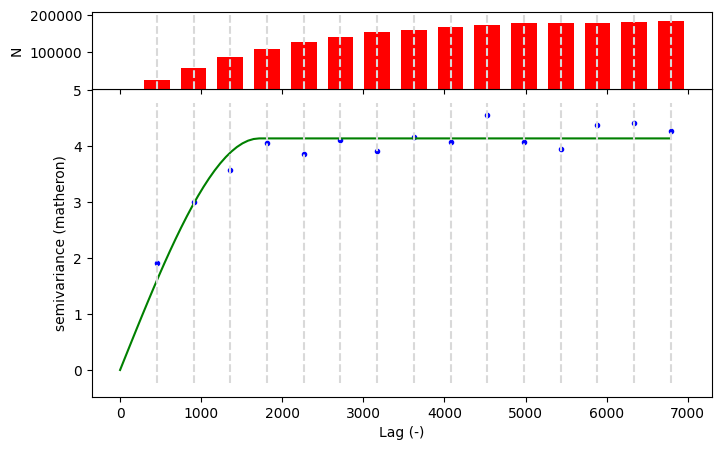

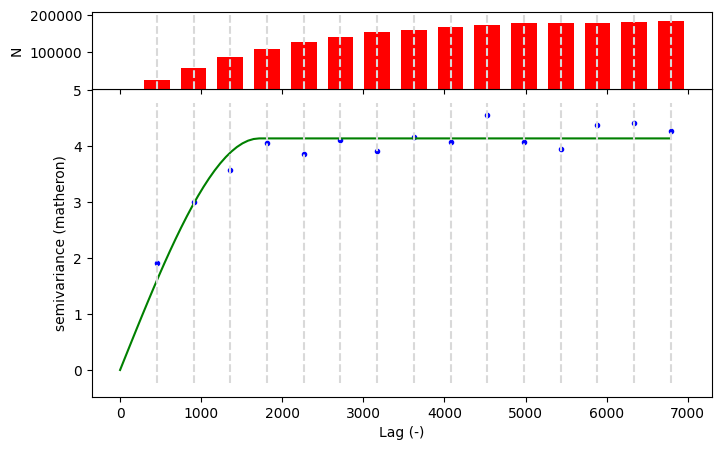

In [21]:


gdf = gdf_join.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = gdf['precio'].values

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

One hot encoding de tipo de inmueble 

In [22]:
gdf = pd.get_dummies(
    gdf,
    columns=['tipo_inmueble'],
    drop_first=True  
).reset_index(drop=True)


# Formulamos y entrenamos modelo

Para cada barrio (si hay datos) vamos a ajustar un modelo geograficamente pesado local, dentro de cada barrio abran multiples modelos para las distintas cantidades 

In [51]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.preprocessing import StandardScaler
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import copy
from pykrige.uk import UniversalKriging


In [24]:
gdf.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'nombre', 'comuna', 'ambientes', 'precio_m2',
       'superficie_por_ambientes', 'tipo_inmueble_departamento',
       'tipo_inmueble_ph'],
      dtype='object')

In [41]:


class SpatialKernelPriceModel:
    def __init__(self, gdf: gpd.GeoDataFrame):
        self._check_data_validity(gdf)

        self.data = gdf
        self.bw_ = None
        self.results_ = None
        self.scaler_ = None   # <-- clave

    # ----------------------------
    # Validaciones
    # ----------------------------
    def _check_data_validity(self, data):
        if not isinstance(data, gpd.GeoDataFrame):
            raise TypeError("Input data must be a GeoDataFrame")

        if data.crs is None:
            raise ValueError("GeoDataFrame must have a CRS defined")

        if data.crs.to_epsg() != 3857:
            raise ValueError(
                f"GeoDataFrame CRS must be EPSG:3857, got {data.crs}"
            )

        if not set(data.geometry.geom_type).issubset({"Point"}):
            raise ValueError("Geometry must be Point for spatial kernel models")

    # ----------------------------
    # Fit
    # ----------------------------
    def fit(self, data: gpd.GeoDataFrame):
        self._check_data_validity(data)
        self.data = data

        gdf = data

        # Coordenadas
        coords = np.column_stack([
            gdf.geometry.x,
            gdf.geometry.y
        ])

        # Variable respuesta (log-precio)
        y = gdf['precio'].values.reshape(-1, 1)

        # Covariables
        X = gdf[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        # -------- Normalización --------
        self.scaler_ = StandardScaler()
        X_std = self.scaler_.fit_transform(X)

        # -------- Selección de bandwidth --------
        bw_selector = Sel_BW(
            coords,
            y,
            X_std,
            spherical=False
        )

        bw = bw_selector.search()

        # -------- GWR --------
        self.gwr_ = GWR(
            coords,
            y,
            X_std,
            bw=bw,
            fixed=False,
            kernel='bisquare'
        )

        self.results_ = self.gwr_.fit()
        self.bw_ = bw

        return self.results_

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, gdf_new: gpd.GeoDataFrame):
        if self.gwr_ is None or self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        self._check_data_validity(gdf_new)

        coords_new = np.column_stack([
            gdf_new.geometry.x,
            gdf_new.geometry.y
        ])

        X_new = gdf_new[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        X_new_std = self.scaler_.transform(X_new)

        gwr_for_pred = copy.deepcopy(self.gwr_)

        preds = gwr_for_pred.predict(
            coords_new,
            X_new_std
        )

        preds = preds.predictions.flatten()


        return preds


    # ----------------------------
    # Summary
    # ----------------------------
    def summary(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        print(self.results_.summary())
        return self.results_.summary()
    
    def results(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")
        return self.results_

In [42]:
gdf = gdf.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.2,
    random_state=42
)

In [43]:

model = SpatialKernelPriceModel(gdf)

model.fit(
    data=gdf_train,
)


In [44]:
model.summary()

Model type                                                         Gaussian
Number of observations:                                                2321
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       42098256879119.250
Log-likelihood:                                                  -30705.845
AIC:                                                              61421.690
AICc:                                                             61423.726
BIC:                                                           42098256861170.820
R2:                                                                   0.588
Adj. R2:                                                              0.587

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- -----

In [45]:
# Predicción en log (como sale del GWR)
y_test_pred = model.predict(
        gdf_test
)

y_test_true = gdf_test['precio'].values
rmse_price = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred
))

rmse_price



np.float64(96298.82137194803)

In [46]:
(y_test_true <= 0).sum()
y_test_true.min(), y_test_true.max()
y_test_pred.min(), y_test_pred.max()

(np.float64(-9063.756012352806), np.float64(2259217.299372737))

In [47]:
res = model.results()
res.tvalues


array([[18.14458951, -1.89933712, -0.38360311,  9.91840408, -0.60896129],
       [ 6.10935858, -0.46791888, -0.36830471,  3.2102343 , -0.26791229],
       [ 5.22444532, -0.86381192,  0.54259512,  2.48061043, -1.45236716],
       ...,
       [ 8.92498518, -2.29440571,  0.30982728,  2.51509098,  0.57852608],
       [16.62494261, -0.94830914,  0.22470282,  4.20570193,  1.51768205],
       [ 6.62213021, -2.2215935 ,  0.78109132, 11.27719729,  1.16315864]],
      shape=(2321, 5))

In [48]:
var_names = ['antiguedad', 'ambientes', 'area_m2', 'expensas']

coefs = pd.DataFrame(
    res.params[:, 1:],   # coeficientes (sin intercepto)
    columns=var_names,
    index=gdf_train.index
)

# coeficientes
for v in var_names:
    gdf_train[f'beta_{v}'] = coefs[v]

# intercepto local
gdf_train["intercept"] = res.params[:, 0]

# R² local
gdf_train["local_R2"] = res.localR2


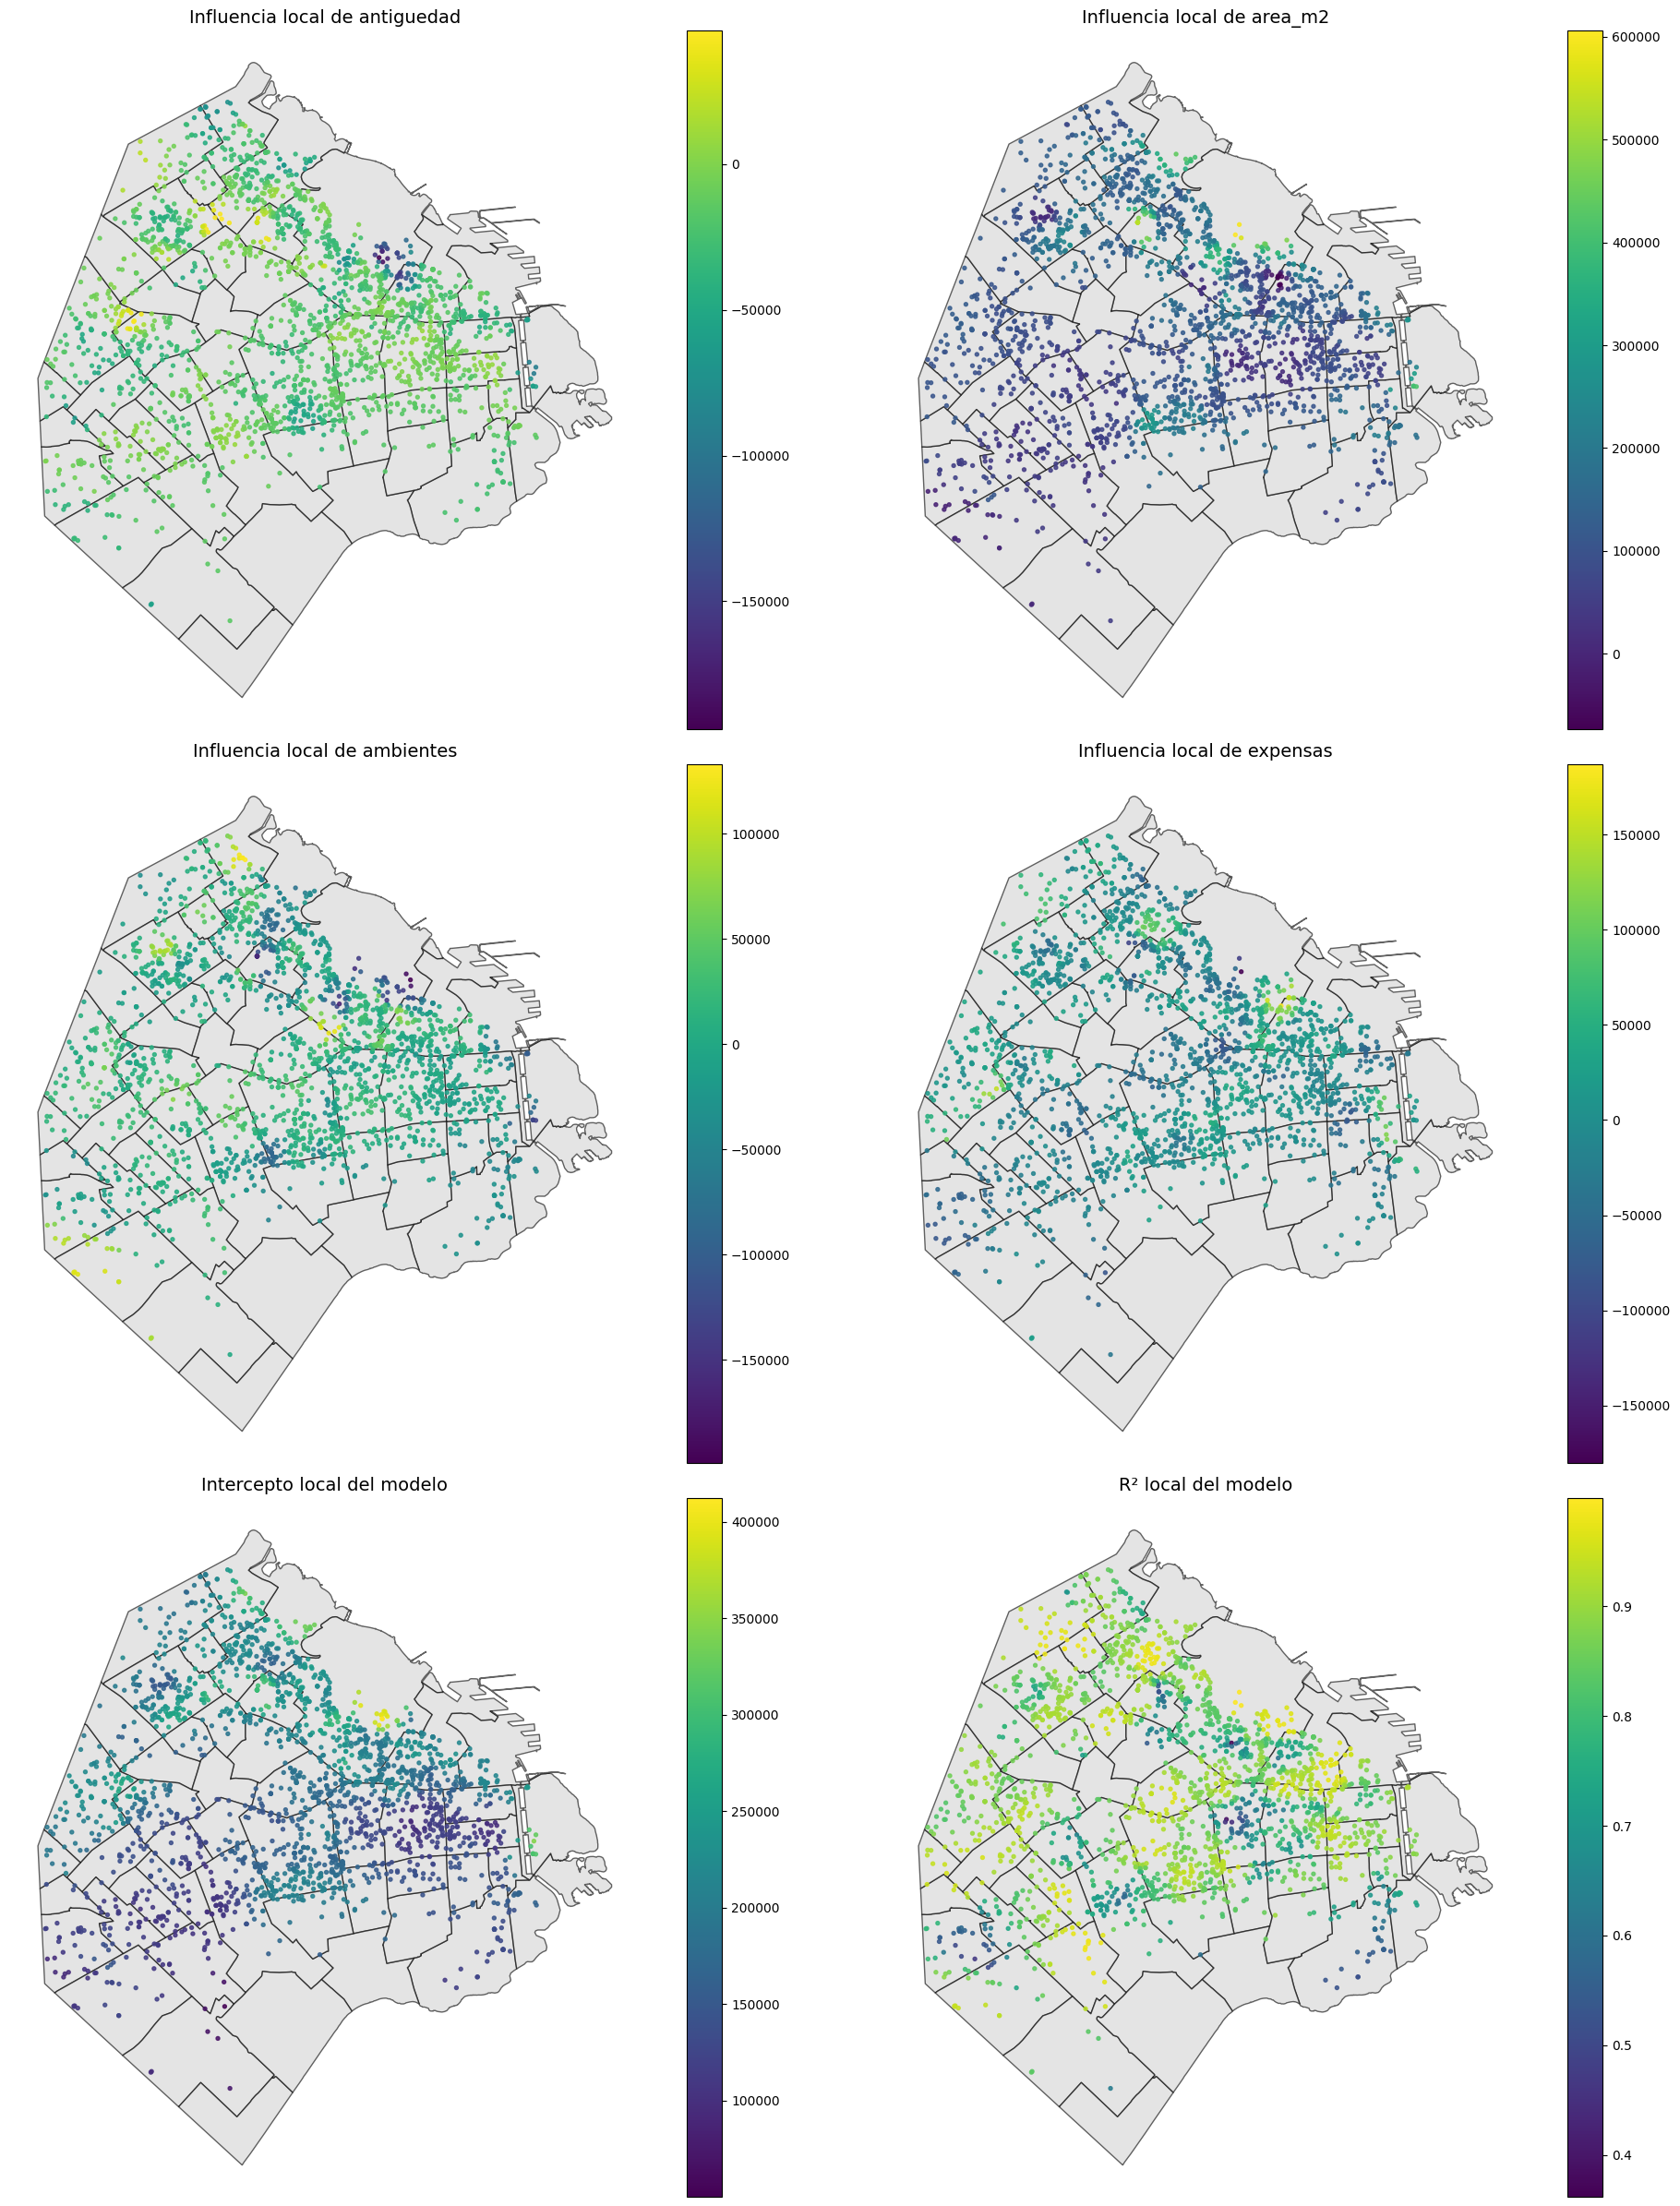

In [49]:
coef_names = [
    "beta_antiguedad", "beta_area_m2", "beta_ambientes",
    "beta_expensas", "intercept", "local_R2"
]

fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()

barrios = barrios.to_crs(epsg=3857)
gdf_train = gdf_train.to_crs(epsg=3857)

for ax, coef in zip(axes, coef_names):

    # ---- fondo: barrios ----
    barrios.plot(
        ax=ax,
        edgecolor="black",
        facecolor="lightgrey",
        alpha=0.6
    )

    # ---- puntos: resultados GWR ----
    gdf_train.plot(
        ax=ax,
        column=coef,
        legend=True,
        markersize=8,
        alpha=0.85
    )

    # ---- títulos más claros ----
    if coef.startswith("beta_"):
        title = f"Influencia local de {coef.replace('beta_', '')}"
    elif coef == "intercept":
        title = "Intercepto local del modelo"
    elif coef == "local_R2":
        title = "R² local del modelo"

    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [34]:
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
significant = np.abs(tvals) > 1.96
significant

(significant).mean() * 100


antiguedad    56.225765
ambientes     54.502370
area_m2       94.872900
expensas      25.118483
dtype: float64

Kriging en residuos. No aporta casi nada asique conviene no tenerlo en cuenta para reducir la complejidad del modelo.

In [35]:
gdf_train = gdf_train.to_crs(epsg=3857)
gdf_test = gdf_test.to_crs(epsg=3857)

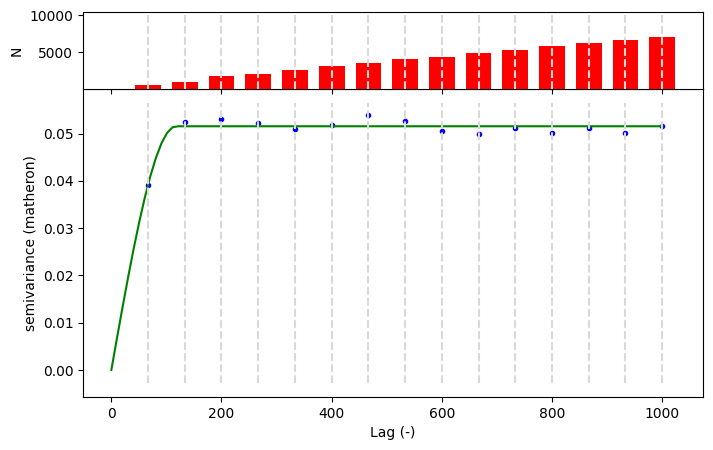

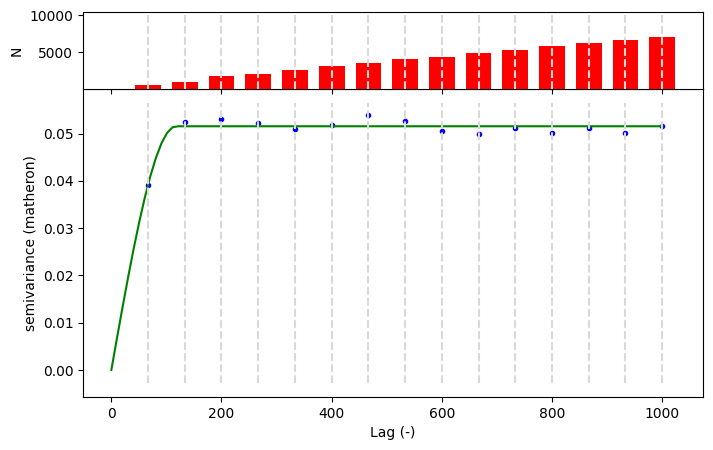

In [36]:

coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])

y_train_true = gdf_train['precio'].values
y_train_pred = model.predict(
        gdf_train
)
residuals = np.log(y_train_true) - np.log(y_train_pred)

V = Variogram(
    coords,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=1000,     # o una distancia en metros
    normalize=False
)
V.plot()

In [53]:
coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])
coords_test = np.column_stack([
    gdf_test.geometry.x,
    gdf_test.geometry.y
])
sill, range_, _ = V.parameters
nugget = 0.0002  
OK = UniversalKriging(
    coords[:,0],
    coords[:,1],
    gdf_train['precio'].values,
    variogram_model='gaussian',
    variogram_parameters=[sill, range_, nugget]
)
z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

In [55]:
y_test_pred_model_y_residual_kriging = y_test_pred + z_pred

rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    z_pred
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    z_pred
)

rmse, mae


(np.float64(150234.0444951926), 90640.91087279588)

In [56]:
print("z_pred stats:")
print("min:", z_pred.min())
print("max:", z_pred.max())
print("mean:", z_pred.mean())
print("std:", z_pred.std())

z_pred stats:
min: 37000.004674193355
max: 1200000.0046093033
mean: 195115.68037817292
std: 84341.40760559555


In [57]:

rmse = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
))

mae = mean_absolute_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
)

rmse, mae

(np.float64(231141.60079938124), 201941.12032038887)

In [58]:
(y_test_pred_model_y_residual_kriging <= 0).sum()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()

(np.float64(68285.80896663821), np.float64(2450485.0070539545))

Local outlier detection con Lisa

In [62]:
from esda.moran import Moran_Local
from libpysal.weights import KNN

gdf.to_crs(epsg=3857)

coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])


w = KNN.from_array(coords, k=15)
w.transform = "r"

y_true = gdf['precio'].values

model_global = SpatialKernelPriceModel(gdf)

model_global.fit(
    data=gdf,
)

y_pred = model_global.predict(
        gdf
)
residuals = y_true - y_pred
lisa = Moran_Local(residuals, w)


In [ ]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf[outliers]

In [67]:
gdf_ml = gdf_train.to_crs(epsg=4326).copy()

gdf_ml['lon'] = gdf_ml.geometry.x
gdf_ml['lat'] = gdf_ml.geometry.y



In [68]:
gdf_ml.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'nombre', 'comuna', 'ambientes', 'precio_m2',
       'superficie_por_ambientes', 'tipo_inmueble_departamento',
       'tipo_inmueble_ph', 'beta_antiguedad', 'beta_ambientes', 'beta_area_m2',
       'beta_expensas', 'intercept', 'local_R2'],
      dtype='object')

In [69]:
features = [
    'lat', 'lon',
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

target = 'precio'

df = gdf_ml[features + [target]].copy()

# eliminar filas con target faltante
df = df.dropna(subset=[target])


In [70]:
from sklearn.impute import SimpleImputer

X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)


In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [73]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))


RF R2: 0.8964694707088147
RF MAE: 36232.95813840246


In [74]:
import pandas as pd

pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)


area_m2       0.419567
expensas      0.172502
ambientes     0.126974
lat           0.107445
lon           0.096077
antiguedad    0.077435
dtype: float64

In [77]:
from esda.moran import Moran_Local
from libpysal.weights import KNN

gdf_ml.to_crs(epsg=3857)

coords = np.column_stack([
    gdf_ml.geometry.x,
    gdf_ml.geometry.y
])


w = KNN.from_array(coords, k=15)
w.transform = "r"


y_pred = rf.predict(
    X_imp
)

residuals = y - y_pred
lisa = Moran_Local(residuals, w)

In [80]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf_ml[outliers]
gdf_ml[outliers].drop(columns="geometry").to_csv(
    "outliers.csv",
    index=False
)
